# Resumen de pruebas para KLEIN (4x4)

Este notebook carga la S-Box `data/clasics/KLEIN.json`, construye y muestra la DDT,
y calcula metricas criptograficas y de cadena de Markov.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sboxes.loader import load as load_sbox
from evaluation.uniformity import get_ddt
from evaluation.fixed_points import fixed_ponts
from evaluation.linearity import evaluate
from evaluation.avalanche_criterion import avalanche_criterion
from evaluation.markov_chains.basic_markov_chain import (
    DifferentialMarkovChain,
    create_transition_matrix,
)

In [2]:
sbox_path = "data/clasics/AES.json"
sbox = load_sbox(sbox_path)
table_hex = [hex(int(v)) for v in sbox.table]

print(f"Nombre: {sbox.name}")
print(f"Dimension: {sbox.input_size}x{sbox.output_size}")
print(f"Tabla ({len(table_hex)} entradas): {table_hex}")

pd.DataFrame({"x": list(range(len(table_hex))), "S(x)": table_hex})

Nombre: AES
Dimension: 8x8
Tabla (256 entradas): ['0x63', '0x7c', '0x77', '0x7b', '0xf2', '0x6b', '0x6f', '0xc5', '0x30', '0x1', '0x67', '0x2b', '0xfe', '0xd7', '0xab', '0x76', '0xca', '0x82', '0xc9', '0x7d', '0xfa', '0x59', '0x47', '0xf0', '0xad', '0xd4', '0xa2', '0xaf', '0x9c', '0xa4', '0x72', '0xc0', '0xb7', '0xfd', '0x93', '0x26', '0x36', '0x3f', '0xf7', '0xcc', '0x34', '0xa5', '0xe5', '0xf1', '0x71', '0xd8', '0x31', '0x15', '0x4', '0xc7', '0x23', '0xc3', '0x18', '0x96', '0x5', '0x9a', '0x7', '0x12', '0x80', '0xe2', '0xeb', '0x27', '0xb2', '0x75', '0x9', '0x83', '0x2c', '0x1a', '0x1b', '0x6e', '0x5a', '0xa0', '0x52', '0x3b', '0xd6', '0xb3', '0x29', '0xe3', '0x2f', '0x84', '0x53', '0xd1', '0x0', '0xed', '0x20', '0xfc', '0xb1', '0x5b', '0x6a', '0xcb', '0xbe', '0x39', '0x4a', '0x4c', '0x58', '0xcf', '0xd0', '0xef', '0xaa', '0xfb', '0x43', '0x4d', '0x33', '0x85', '0x45', '0xf9', '0x2', '0x7f', '0x50', '0x3c', '0x9f', '0xa8', '0x51', '0xa3', '0x40', '0x8f', '0x92', '0x9d', '0x38', '0xf5

,x,S(x)
0,0,0x63
1,1,0x7c
2,2,0x77
3,3,0x7b
4,4,0xf2
...,...,...
251,251,0xf
252,252,0xb0
253,253,0x54
254,254,0xbb


In [3]:
ddt = get_ddt(sbox)
ddt_df = pd.DataFrame(
    ddt,
    index=[f"dx={i}" for i in range(ddt.shape[0])],
    columns=[f"dy={j}" for j in range(ddt.shape[1])],
)
ddt_df

,dy=0,dy=1,dy=2,dy=3,dy=4,dy=5,dy=6,dy=7,dy=8,dy=9,...,dy=246,dy=247,dy=248,dy=249,dy=250,dy=251,dy=252,dy=253,dy=254,dy=255
dx=0,256,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dx=1,0,2,0,0,2,0,2,0,2,2,...,2,2,2,0,2,2,0,0,0,2
dx=2,0,0,0,2,2,2,2,2,0,0,...,0,2,0,0,2,0,0,2,2,2
dx=3,0,0,2,0,2,2,0,0,2,0,...,0,2,2,2,2,2,0,2,0,2
dx=4,0,0,0,0,0,0,0,0,0,2,...,2,0,0,2,2,2,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dx=251,0,0,0,0,0,2,0,2,2,2,...,0,0,2,0,2,0,0,0,2,0
dx=252,0,2,0,0,2,2,0,0,0,0,...,0,2,0,2,0,0,2,0,2,2
dx=253,0,0,2,2,2,2,0,2,0,2,...,0,2,0,0,0,0,0,2,0,2
dx=254,0,0,0,2,2,0,0,2,2,2,...,2,2,2,2,0,2,2,2,0,2


In [7]:
ddt_df.to_csv("ddtAES.csv")

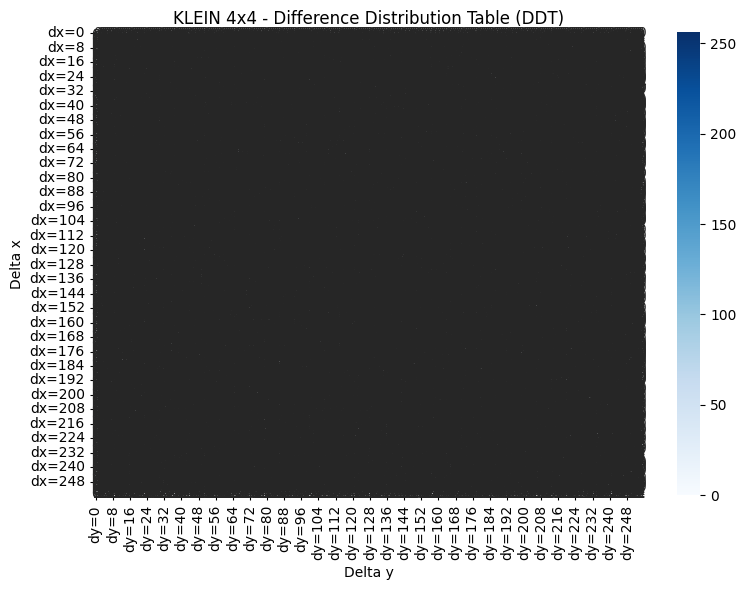

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(ddt_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("KLEIN 4x4 - Difference Distribution Table (DDT)")
plt.xlabel("Delta y")
plt.ylabel("Delta x")
plt.tight_layout()
plt.show()

In [5]:
avg_sac, sac_per_input, std_per_input, max_std = avalanche_criterion(sbox)
fixed_points = int(fixed_ponts(sbox, detail=True)[1])
max_ddt = int(ddt.max())
uniformity = int(ddt[1:].max()) if ddt.shape[0] > 1 else max_ddt

transition_matrix = create_transition_matrix(
    np.asarray(sbox.table, dtype=np.int64),
    int(sbox.input_size),
    int(sbox.output_size),
    skip_zero=True,
)
chain = DifferentialMarkovChain(transition_matrix)

metrics_df = pd.DataFrame([
    {
        "name": sbox.name,
        "input_size": int(sbox.input_size),
        "output_size": int(sbox.output_size),
        "uniformity": uniformity,
        "max_ddt": max_ddt,
        "fixed_points": fixed_points,
        "non_linearity": float(evaluate(sbox)),
        "avg_sac": float(avg_sac),
        "max_std_sac": float(max_std),
        "sac_per_input": [float(x) for x in np.round(sac_per_input, 6)],
        "std_sac_per_input": [float(x) for x in np.round(std_per_input, 6)],
        "spectral_gap": float(chain.spectral_gap()),
        "tv_distance_r4": float(chain.tv_distance(4)),
        "max_probability_r4": float(chain.max_probability(4)),
        "mixing_time_eps_1e-3": int(chain.mixing_time_iterative(epsilon=1e-3, max_steps=10_000)),
        "mixing_time_spectral_eps_1e-3": float(chain.mixing_time_spectral(eps=1e-3)),
    }
])

metrics_df

,name,input_size,output_size,uniformity,max_ddt,fixed_points,non_linearity,avg_sac,max_std_sac,sac_per_input,std_sac_per_input,spectral_gap,tv_distance_r4,max_probability_r4,mixing_time_eps_1e-3,mixing_time_spectral_eps_1e-3
0,AES,8,8,4,256,0,112.0,0.504883,0.036644,"[0.492188, 0.498047, 0.511719, 0.507812, 0.5, ...","[0.036644, 0.032624, 0.025615, 0.03125, 0.0312...",0.935879,0.000109,0.003926,4,7.0


In [6]:
metrics_df.to_csv("klein_metrics_summary.csv", index=False)
ddt_df.to_csv("klein_ddt.csv", index=True)
print("Guardado: klein_metrics_summary.csv")
print("Guardado: klein_ddt.csv")

Guardado: klein_metrics_summary.csv
Guardado: klein_ddt.csv
